**Step 1 — Data Ingestion & AAMI Mapping**

In [1]:
!pip install wfdb
import torch
import os
import pickle
import numpy as np
import wfdb

print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: None (running on CPU)")

AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q',
}

CLASS2IDX = {'N':0,'S':1,'V':2,'F':3,'Q':4}

MIT_BIH_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

def load_record(record_id, data_dir='mitdb'):
    path   = os.path.join(data_dir, record_id)
    record = wfdb.rdrecord(path)
    annot  = wfdb.rdann(path, 'atr')
    signal = record.p_signal  # (N, 2)
    fs     = record.fs
    return signal, fs, annot.sample, annot.symbol


def extract_beats(signal, fs, r_peaks, symbols, before=150, after=150):
    # Empty return always has shape (0, before+after, 2) so that
    # transpose(0, 2, 1) in Step 2 is always safe, even for records
    # that yield zero valid beats.
    beats, labels = [], []
    win = before + after

    for peak, sym in zip(r_peaks, symbols):
        aami = AAMI_MAP.get(sym)
        if aami is None:
            continue
        start = peak - before
        end   = peak + after
        if start < 0 or end > signal.shape[0]:
            continue
        beats.append(signal[start:end, :])
        labels.append(CLASS2IDX[aami])

    if len(labels) == 0:
        return (np.empty((0, win, 2), dtype=np.float32),
                np.empty((0,), dtype=np.int64))

    return (np.array(beats, dtype=np.float32),
            np.array(labels, dtype=np.int64))


def main():
    os.makedirs('mitdb',     exist_ok=True)
    os.makedirs('processed', exist_ok=True)

    print("Downloading MIT-BIH dataset...")
    wfdb.dl_database('mitdb', dl_dir='mitdb',
                     records=MIT_BIH_RECORDS, overwrite=False)
    print("Download complete.")

    subject_data = {}
    for rec in MIT_BIH_RECORDS:
        print(f"Processing {rec}...")
        signal, fs, r_peaks, symbols = load_record(rec)
        beats, labels = extract_beats(signal, fs, r_peaks, symbols)
        subject_data[rec] = {'beats': beats, 'labels': labels}
        if len(labels) > 0:
            print(f"  -> {len(labels)} beats | class dist: "
                  f"{np.bincount(labels, minlength=5)}")
        else:
            print("  -> No valid beats extracted")

    with open('processed/subject_data.pkl', 'wb') as f:
        pickle.dump(subject_data, f)
    print("Saved: processed/subject_data.pkl")


if __name__ == "__main__":
    main()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.4 MB/s eta 0:00:0000:01
CUDA Available: True
GPU: Tesla T4
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating recor

**Step 2 — Leak-Free LOSO Fold Builder**

In [2]:
import pickle
import numpy as np


# ---------------------------------------------------------------------
# PATIENT MAPPING
# In the MIT-BIH Arrhythmia Database, every record maps to a unique
# patient EXCEPT records 201 and 202, which come from the same subject
# (per the official database documentation). Grouping by patient_id
# instead of record_id ensures a true leave-one-subject-out (LOSO)
# split -- no patient's beats can appear in both train and test.
# ---------------------------------------------------------------------
def build_patient_groups(record_ids):
    """Map each record_id to a patient_id, merging the one known
    same-patient pair (201, 202) into a single patient group."""
    patient_of = {}
    for r in record_ids:
        patient_of[r] = r  # default: record_id == patient_id

    if '201' in patient_of and '202' in patient_of:
        patient_of['202'] = '201'  # 202 belongs to the same patient as 201

    groups = {}
    for r, pid in patient_of.items():
        groups.setdefault(pid, []).append(r)
    return groups  # {patient_id: [record_id, ...]}


def fit_normalize_train(X_train):
    # X_train: (N, C, T)  ->  mean/std shape (1, C, 1)
    # Fitted ONLY on the training fold, then reused (never refit) on
    # test data -- this is the key leakage guard for normalization.
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
    return (X_train - mean) / std, mean, std


def normalize_test(X_test, mean, std):
    return (X_test - mean) / std


def build_loso_folds(subject_data):
    """True leave-one-SUBJECT-out folds: all records belonging to the
    same patient are held out together, so no patient's beats ever
    appear in both the training and test sets of a fold."""
    record_ids = list(subject_data.keys())
    patient_groups = build_patient_groups(record_ids)
    patient_ids = list(patient_groups.keys())

    folds = []

    for i, test_patient in enumerate(patient_ids):
        test_records  = patient_groups[test_patient]
        train_records = [r for r in record_ids if r not in test_records]

        X_train_list = [subject_data[r]['beats']
                        for r in train_records
                        if subject_data[r]['beats'].shape[0] > 0]
        y_train_list = [subject_data[r]['labels']
                        for r in train_records
                        if subject_data[r]['beats'].shape[0] > 0]

        X_test_list = [subject_data[r]['beats']
                       for r in test_records
                       if subject_data[r]['beats'].shape[0] > 0]
        y_test_list = [subject_data[r]['labels']
                       for r in test_records
                       if subject_data[r]['beats'].shape[0] > 0]

        if len(X_train_list) == 0 or len(X_test_list) == 0:
            print(f"Skipping fold {test_patient} (empty data)")
            continue

        X_train = np.concatenate(X_train_list, axis=0)  # (N, 300, 2)
        y_train = np.concatenate(y_train_list, axis=0)
        X_test  = np.concatenate(X_test_list, axis=0)   # (M, 300, 2)
        y_test  = np.concatenate(y_test_list, axis=0)

        X_train = X_train.transpose(0, 2, 1)  # (N, 2, 300)
        X_test  = X_test.transpose(0, 2, 1)   # (M, 2, 300)

        # Normalization statistics are computed from TRAIN ONLY and then
        # applied to test -- no test-set information leaks into scaling.
        X_train_norm, mean, std = fit_normalize_train(X_train)
        X_test_norm             = normalize_test(X_test, mean, std)

        folds.append({
            "test_id" : "+".join(test_records),  # e.g. "201+202"
            "patient_id": test_patient,
            "X_train" : X_train_norm.astype(np.float32),
            "y_train" : y_train.astype(np.int64),
            "X_test"  : X_test_norm.astype(np.float32),
            "y_test"  : y_test.astype(np.int64),
            "mean"    : mean,
            "std"     : std
        })
        print(f"Fold {i+1:02d} | test_patient={test_patient} "
              f"(records={'+'.join(test_records)}) | "
              f"train={X_train_norm.shape[0]} | "
              f"test={X_test_norm.shape[0]}")

    return folds


if __name__ == "__main__":
    with open("processed/subject_data.pkl", "rb") as f:
        subject_data = pickle.load(f)
    folds = build_loso_folds(subject_data)
    with open("processed/loso_folds.pkl", "wb") as f:
        pickle.dump(folds, f)
    print(f"Saved processed/loso_folds.pkl ({len(folds)} true patient-independent folds)")


Fold 01 | test_patient=100 (records=100) | train=107173 | test=2271
Fold 02 | test_patient=101 (records=101) | train=107580 | test=1864
Fold 03 | test_patient=102 (records=102) | train=107259 | test=2185
Fold 04 | test_patient=103 (records=103) | train=107361 | test=2083
Fold 05 | test_patient=104 (records=104) | train=107217 | test=2227
Fold 06 | test_patient=105 (records=105) | train=106872 | test=2572
Fold 07 | test_patient=106 (records=106) | train=107417 | test=2027
Fold 08 | test_patient=107 (records=107) | train=107308 | test=2136
Fold 09 | test_patient=108 (records=108) | train=107682 | test=1762
Fold 10 | test_patient=109 (records=109) | train=106914 | test=2530
Fold 11 | test_patient=111 (records=111) | train=107320 | test=2124
Fold 12 | test_patient=112 (records=112) | train=106907 | test=2537
Fold 13 | test_patient=113 (records=113) | train=107650 | test=1794
Fold 14 | test_patient=114 (records=114) | train=107565 | test=1879
Fold 15 | test_patient=115 (records=115) | train

**Step 3 — Imbalance Handling (Leakage-Safe)**

In [3]:
%%writefile step3_imbalance.py
import pickle
import numpy as np
import os
from collections import Counter


def compute_class_weights(y_train, n_classes=5):
    counts = np.bincount(y_train, minlength=n_classes).astype(float)
    counts[counts == 0] = 1.0
    weights = 1.0 / counts
    weights = weights / weights.sum() * n_classes
    return weights.astype(np.float32)


def simple_oversample(X, y, target_max_ratio=1.0):
    # Oversampling is computed and applied to the TRAINING fold only,
    # after the LOSO split -- the test set is never touched, so no
    # duplicated beats can leak across the train/test boundary.
    dist      = Counter(y)
    max_count = max(dist.values())
    target    = int(max_count * target_max_ratio)

    X_list, y_list = [], []
    for cls in sorted(dist):
        idx   = np.where(y == cls)[0]
        cls_X = X[idx]
        cls_y = y[idx]
        if len(idx) < target:
            reps  = target // len(idx) + 1
            cls_X = np.tile(cls_X, (reps, 1, 1))[:target]
            cls_y = np.tile(cls_y,  reps)[:target]
        else:
            cls_X = cls_X[:target]
            cls_y = cls_y[:target]
        X_list.append(cls_X)
        y_list.append(cls_y)

    X_res = np.concatenate(X_list, axis=0)
    y_res = np.concatenate(y_list, axis=0)
    perm  = np.random.permutation(len(y_res))
    return X_res[perm], y_res[perm]


def process_fold(fold, use_oversampling=False):
    X_train = fold["X_train"]
    y_train = fold["y_train"]
    print("Before:", dict(Counter(y_train)))
    if use_oversampling:
        X_train, y_train = simple_oversample(X_train, y_train)
        print("After oversampling:", dict(Counter(y_train)))
    weights = compute_class_weights(y_train)
    print("Class weights:", weights)
    return X_train, y_train, weights


if __name__ == "__main__":
    loso_folds_path = "processed/loso_folds.pkl"
    if not os.path.exists(loso_folds_path):
        raise FileNotFoundError(
            "loso_folds.pkl not found. Run step2_loso_folds.py first.")
    with open(loso_folds_path, "rb") as f:
        folds = pickle.load(f)
    X_train, y_train, weights = process_fold(folds[0], use_oversampling=False)


Writing step3_imbalance.py


**Step 4 — BiLSTM-ECG Model (Dual-Stream Bidirectional LSTM)**

In [4]:
%%writefile step4_model.py
import torch
import torch.nn as nn


class AttentionPooling(nn.Module):
    """Learnable additive attention pooling over a sequence of hidden
    states. Replaces simple last-timestep/mean pooling so the model can
    weight the most informative timesteps (or beats) more heavily."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (B, T, H)
        scores  = self.attn(x)                     # (B, T, 1)
        weights = torch.softmax(scores, dim=1)      # (B, T, 1)
        pooled  = (x * weights).sum(dim=1)          # (B, H)
        return pooled


class IntraBeatBiLSTM(nn.Module):
    """Encodes a single ECG beat (n_leads, seq_len) into a fixed-length
    representation by running a stacked Bidirectional LSTM over the
    time axis and attention-pooling the resulting hidden states.

    This is the BiLSTM counterpart of the Transformer's PatchEmbedding
    + intra-beat Transformer encoder: same job (turn one beat into one
    vector), different mechanism (recurrence instead of self-attention).
    """
    def __init__(self, n_leads=2, hidden_dim=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_leads,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.pool = AttentionPooling(hidden_dim * 2)
        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, C, T) -> (B, T, C) because nn.LSTM expects
        # (batch, seq_len, input_size) with batch_first=True.
        x = x.transpose(1, 2)
        out, _ = self.lstm(x)            # (B, T, 2*hidden_dim)
        pooled = self.pool(out)          # (B, 2*hidden_dim)
        return self.drop(self.norm(pooled))


class InterBeatBiLSTM(nn.Module):
    """Models rhythm context across a sequence of beat embeddings
    (the focal beat plus its surrounding beats) using a second,
    independent Bidirectional LSTM.

    This is the BiLSTM counterpart of the Transformer's
    InterBeatTransformer: it captures how the focal beat relates to
    its neighbors (rhythm-level information), but via sequential
    recurrence rather than self-attention over a CLS token.
    """
    def __init__(self, in_dim=128, hidden_dim=64, n_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=in_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.pool = AttentionPooling(hidden_dim * 2)
        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, S, D)
        out, _ = self.lstm(x)            # (B, S, 2*hidden_dim)
        pooled = self.pool(out)          # (B, 2*hidden_dim)
        return self.drop(self.norm(pooled))


class BiLSTMECGClassifier(nn.Module):
    """Dual-stream Bidirectional LSTM classifier for patient-independent
    ECG arrhythmia classification.

    Architecture mirrors the Transformer baseline's two-stream design:
      1. IntraBeatBiLSTM encodes the focal beat AND every context beat
         independently into fixed-length vectors.
      2. InterBeatBiLSTM consumes the sequence [focal, context_1, ...,
         context_S] to model local rhythm dynamics.
      3. The focal-beat embedding and the rhythm embedding are fused
         and passed to a linear classification head.

    Input/output contract is identical to the Transformer model so it
    is a drop-in replacement: no changes needed to the Dataset,
    DataLoader, imbalance handling, loss, or training loop.
    """
    def __init__(self, n_classes=5, intra_hidden=64, inter_hidden=64,
                 intra_layers=2, inter_layers=1, dropout=0.3):
        super().__init__()
        self.intra = IntraBeatBiLSTM(
            hidden_dim=intra_hidden, n_layers=intra_layers, dropout=dropout)
        intra_out_dim = intra_hidden * 2  # bidirectional concat

        self.inter = InterBeatBiLSTM(
            in_dim=intra_out_dim, hidden_dim=inter_hidden,
            n_layers=inter_layers, dropout=dropout)
        inter_out_dim = inter_hidden * 2  # bidirectional concat

        self.fusion = nn.Sequential(
            nn.Linear(intra_out_dim + inter_out_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(128, n_classes)

    def forward(self, beat, context):
        # beat:    (B, 2, 300)         single focal beat
        # context: (B, S, 2, 300)      S surrounding beats
        B, S, C, T = context.shape

        beat_repr = self.intra(beat)                          # (B, D)

        ctx      = context.reshape(B * S, C, T)
        ctx_repr = self.intra(ctx).reshape(B, S, -1)          # (B, S, D)

        seq    = torch.cat([beat_repr.unsqueeze(1), ctx_repr], dim=1)  # (B, S+1, D)
        rhythm = self.inter(seq)                              # (B, D2)

        fused = self.fusion(torch.cat([beat_repr, rhythm], dim=-1))
        return self.classifier(fused)


if __name__ == "__main__":
    model   = BiLSTMECGClassifier()
    beat    = torch.randn(4, 2, 300)
    context = torch.randn(4, 8, 2, 300)
    out     = model(beat, context)
    print("Output shape:", out.shape)   # (4, 5)
    print("Total params:", sum(p.numel() for p in model.parameters()))


Writing step4_model.py


**Step 5 — Focal Loss**

In [5]:
%%writefile step5_loss.py
import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        if class_weights is not None:
            self.register_buffer(
                "class_weights",
                torch.tensor(class_weights, dtype=torch.float32)
            )
        else:
            self.class_weights = None

    def forward(self, logits, targets):
        # class_weights (per-class) + focal modulation (per-sample) do NOT
        # double-count: they are complementary weighting strategies.
        ce   = F.cross_entropy(logits, targets,
                               weight=self.class_weights, reduction="none")
        probs = F.softmax(logits, dim=-1)
        pt    = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt    = torch.clamp(pt, min=1e-7, max=1.0)
        return ((1.0 - pt) ** self.gamma * ce).mean()


Writing step5_loss.py


**Step 6 — Dataset & DataLoader**

In [6]:
%%writefile step6_dataset.py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


class ECGContextDataset(Dataset):

    def __init__(self, X, y, context_size=8, augment=False):
        assert context_size % 2 == 0, "context_size must be even"
        self.X            = torch.from_numpy(np.ascontiguousarray(X)).float()
        self.y            = torch.from_numpy(np.ascontiguousarray(y)).long()
        self.context_size = context_size
        self.half         = context_size // 2
        self.augment      = augment
        self.N            = len(y)

    def __len__(self):
        return self.N

    def _get_context_indices(self, idx):
        # True reflection padding at sequence boundaries: -1 -> 1,
        # N -> N-2, etc., with a final clamp as a safety net.
        indices = []
        for offset in range(-self.half, self.half + 1):
            if offset == 0:
                continue
            j = idx + offset
            if j < 0:
                j = -j                   # reflect: -1->1, -2->2
            elif j >= self.N:
                j = 2 * self.N - j - 2  # reflect from far end
            j = max(0, min(self.N - 1, j))  # final clamp safety net
            indices.append(j)
        return torch.tensor(indices, dtype=torch.long)

    def __getitem__(self, idx):
        focal       = self.X[idx]
        label       = self.y[idx]
        ctx_indices = self._get_context_indices(idx)
        context     = self.X[ctx_indices]
        if self.augment:
            focal, context = self._augment(focal, context)
        return focal, context, label

    def _augment(self, focal, context):
        if torch.rand(1).item() < 0.5:
            focal   = focal   + 0.005 * torch.randn_like(focal)
            context = context + 0.005 * torch.randn_like(context)
        if torch.rand(1).item() < 0.3:
            scale   = 0.9 + 0.2 * torch.rand(1)
            focal   = focal   * scale
            context = context * scale
        return focal, context


def get_dataloaders(X_train, y_train, X_test, y_test,
                    batch_size=64, context_size=8, num_workers=0):
    # num_workers defaults to 0 (safe for notebooks); pin_memory only
    # engaged when num_workers > 0.
    train_ds = ECGContextDataset(X_train, y_train,
                                  context_size=context_size, augment=True)
    test_ds  = ECGContextDataset(X_test,  y_test,
                                  context_size=context_size, augment=False)
    train_dl = DataLoader(train_ds, batch_size=batch_size,
                          shuffle=True,  num_workers=num_workers,
                          pin_memory=(num_workers > 0))
    test_dl  = DataLoader(test_ds,  batch_size=128,
                          shuffle=False, num_workers=num_workers,
                          pin_memory=(num_workers > 0))
    return train_dl, test_dl


Writing step6_dataset.py


**Step 7 — Training Loop (Single Fold)**

In [7]:
%%writefile step7_training_loop.py
import torch
import numpy as np
from torch.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import f1_score, accuracy_score

from step4_model      import BiLSTMECGClassifier
from step5_loss       import FocalLoss
from step6_dataset    import get_dataloaders
from step3_imbalance  import compute_class_weights


def train_fold(fold, fold_idx, device="cuda", epochs=15,
               batch_size=64, lr=3e-4, context_size=8, patience=4):

    X_tr, y_tr = fold["X_train"], fold["y_train"]
    X_te, y_te = fold["X_test"],  fold["y_test"]

    # Class weights are computed from the TRAINING fold's labels only --
    # the test fold never influences the loss weighting.
    class_weights = compute_class_weights(y_tr)
    train_dl, test_dl = get_dataloaders(X_tr, y_tr, X_te, y_te,
                                        batch_size=batch_size,
                                        context_size=context_size)

    model       = BiLSTMECGClassifier().to(device)
    criterion   = FocalLoss(class_weights=class_weights).to(device)
    optimizer   = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler   = OneCycleLR(optimizer, max_lr=lr,
                             steps_per_epoch=len(train_dl), epochs=epochs,
                             pct_start=0.1, anneal_strategy="cos")

    use_amp = (device == "cuda")
    scaler  = GradScaler(enabled=use_amp)

    best_f1, best_state, patience_counter = 0.0, None, 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for focal, context, labels in train_dl:
            focal, context, labels = (focal.to(device),
                                      context.to(device),
                                      labels.to(device))
            optimizer.zero_grad()
            with autocast(device_type="cuda" if use_amp else "cpu",
                          enabled=use_amp):
                logits = model(focal, context)
                loss   = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            # Gradient clipping is especially important for LSTMs, which
            # are more prone to exploding gradients than Transformers.
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_loss += loss.item()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for focal, context, labels in test_dl:
                focal, context = focal.to(device), context.to(device)
                with autocast(device_type="cuda" if use_amp else "cpu",
                              enabled=use_amp):
                    logits = model(focal, context)
                all_preds.extend(logits.argmax(dim=1).cpu().numpy())
                all_labels.extend(labels.numpy())

        macro_f1 = f1_score(all_labels, all_preds,
                            average="macro", zero_division=0)
        acc      = accuracy_score(all_labels, all_preds)
        print(f"Fold {fold_idx:02d} | Ep {epoch:03d} | "
              f"loss={total_loss/len(train_dl):.4f} | "
              f"acc={acc:.4f} | macro-F1={macro_f1:.4f}")

        if macro_f1 > best_f1:
            best_f1, patience_counter = macro_f1, 0
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    if best_state is None:
        best_state = {k: v.cpu().clone()
                      for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_labels, all_logits = [], [], []
    with torch.no_grad():
        for focal, context, labels in test_dl:
            focal, context = focal.to(device), context.to(device)
            logits = model(focal, context)

            probs = torch.softmax(logits, dim=1)

            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_logits.extend(probs.cpu().numpy())

    return {
        "test_id"    : fold["test_id"],
        "preds"      : np.array(all_preds),
        "labels"     : np.array(all_labels),
        "logits"     : np.array(all_logits),
        "best_f1"    : best_f1,
        "best_state" : best_state
    }


Writing step7_training_loop.py


**Step 8 — Full LOSO Runner**

In [8]:
import pickle
import torch
import os
import json
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from step7_training_loop import train_fold

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CLASS_NAMES = ["N", "S", "V", "F", "Q"]
ALL_LABELS = [0, 1, 2, 3, 4]


def run_loso():

    with open("processed/loso_folds.pkl", "rb") as f:
        folds = pickle.load(f)

    os.makedirs("results", exist_ok=True)

    all_results = []

    for i, fold in enumerate(folds):

        print(
            f"\n=== LOSO Fold {i+1}/{len(folds)} | "
            f"test={fold['test_id']} ==="
        )

        try:
            result = train_fold(
                fold,
                fold_idx=i + 1,
                device=DEVICE
            )

        except Exception as e:

            print(
                f"[WARNING] Fold {i+1} failed: {e}"
            )
            continue

        acc = accuracy_score(
            result["labels"],
            result["preds"]
        )

        macro_f1 = f1_score(
            result["labels"],
            result["preds"],
            average="macro",
            zero_division=0
        )

        report_text = classification_report(
            result["labels"],
            result["preds"],
            labels=ALL_LABELS,
            target_names=CLASS_NAMES,
            zero_division=0
        )

        cm = confusion_matrix(
            result["labels"],
            result["preds"],
            labels=ALL_LABELS
        )

        print(report_text)

        all_results.append({

            "fold": i + 1,
            "test_id": fold["test_id"],

            "accuracy": float(acc),
            "macro_f1": float(macro_f1),
            "best_f1": float(result["best_f1"]),

            "confusion_matrix": cm.tolist(),

            "preds": result["preds"].tolist(),
            "labels": result["labels"].tolist(),
            "logits": result["logits"].tolist()
        })

    if len(all_results) == 0:

        print(
            "No folds completed successfully."
        )
        return

    all_preds = np.concatenate(
        [r["preds"] for r in all_results]
    )

    all_labels = np.concatenate(
        [r["labels"] for r in all_results]
    )

    overall_acc = accuracy_score(
        all_labels,
        all_preds
    )

    overall_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    report_text = classification_report(
        all_labels,
        all_preds,
        labels=ALL_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )

    report_dict = classification_report(
        all_labels,
        all_preds,
        labels=ALL_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
        output_dict=True
    )

    agg_cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=ALL_LABELS
    )

    print("\n===== AGGREGATE LOSO RESULTS =====")

    print(
        f"Overall accuracy : {overall_acc:.4f}"
    )

    print(
        f"Overall macro-F1 : {overall_f1:.4f}"
    )

    print(report_text)

    print(
        "Confusion matrix:\n",
        agg_cm
    )

    summary = {

        "overall_accuracy":
            float(overall_acc),

        "overall_macro_f1":
            float(overall_f1),

        "per_fold_macro_f1":
            [float(r["macro_f1"])
             for r in all_results],

        "per_fold_accuracy":
            [float(r["accuracy"])
             for r in all_results],

        "per_fold_best_val_f1":
            [float(r["best_f1"])
             for r in all_results],

        "aggregate_confusion_matrix":
            agg_cm.tolist(),

        "classification_report":
            report_dict
    }

    with open(
        "results/loso_summary.json",
        "w"
    ) as f:

        json.dump(
            summary,
            f,
            indent=2
        )

    with open(
        "results/all_results.pkl",
        "wb"
    ) as f:

        pickle.dump(
            all_results,
            f
        )

    print(
        "\nSaved:"
    )

    print(
        "results/loso_summary.json"
    )

    print(
        "results/all_results.pkl"
    )


if __name__ == "__main__":
    run_loso()



=== LOSO Fold 1/47 | test=100 ===
Fold 01 | Ep 001 | loss=0.0947 | acc=0.9621 | macro-F1=0.4952
Fold 01 | Ep 002 | loss=0.0379 | acc=0.9423 | macro-F1=0.4926
Fold 01 | Ep 003 | loss=0.0251 | acc=0.7781 | macro-F1=0.2193
Fold 01 | Ep 004 | loss=0.0195 | acc=0.4936 | macro-F1=0.4223
Fold 01 | Ep 005 | loss=0.0159 | acc=0.9837 | macro-F1=0.4979
Fold 01 | Ep 006 | loss=0.0133 | acc=0.9828 | macro-F1=0.6638
Fold 01 | Ep 007 | loss=0.0120 | acc=0.9714 | macro-F1=0.6718
Fold 01 | Ep 008 | loss=0.0107 | acc=0.9291 | macro-F1=0.4908
Fold 01 | Ep 009 | loss=0.0097 | acc=0.9833 | macro-F1=0.4979
Fold 01 | Ep 010 | loss=0.0088 | acc=0.9089 | macro-F1=0.6690
Fold 01 | Ep 011 | loss=0.0081 | acc=0.7028 | macro-F1=0.6231
Early stopping at epoch 11
              precision    recall  f1-score   support

           N       0.99      0.99      0.99      2237
           S       0.03      0.03      0.03        33
           V       1.00      1.00      1.00         1
           F       0.00      0.00      

**Step 9 — Visualization**

Saved visualizations to results/*.png


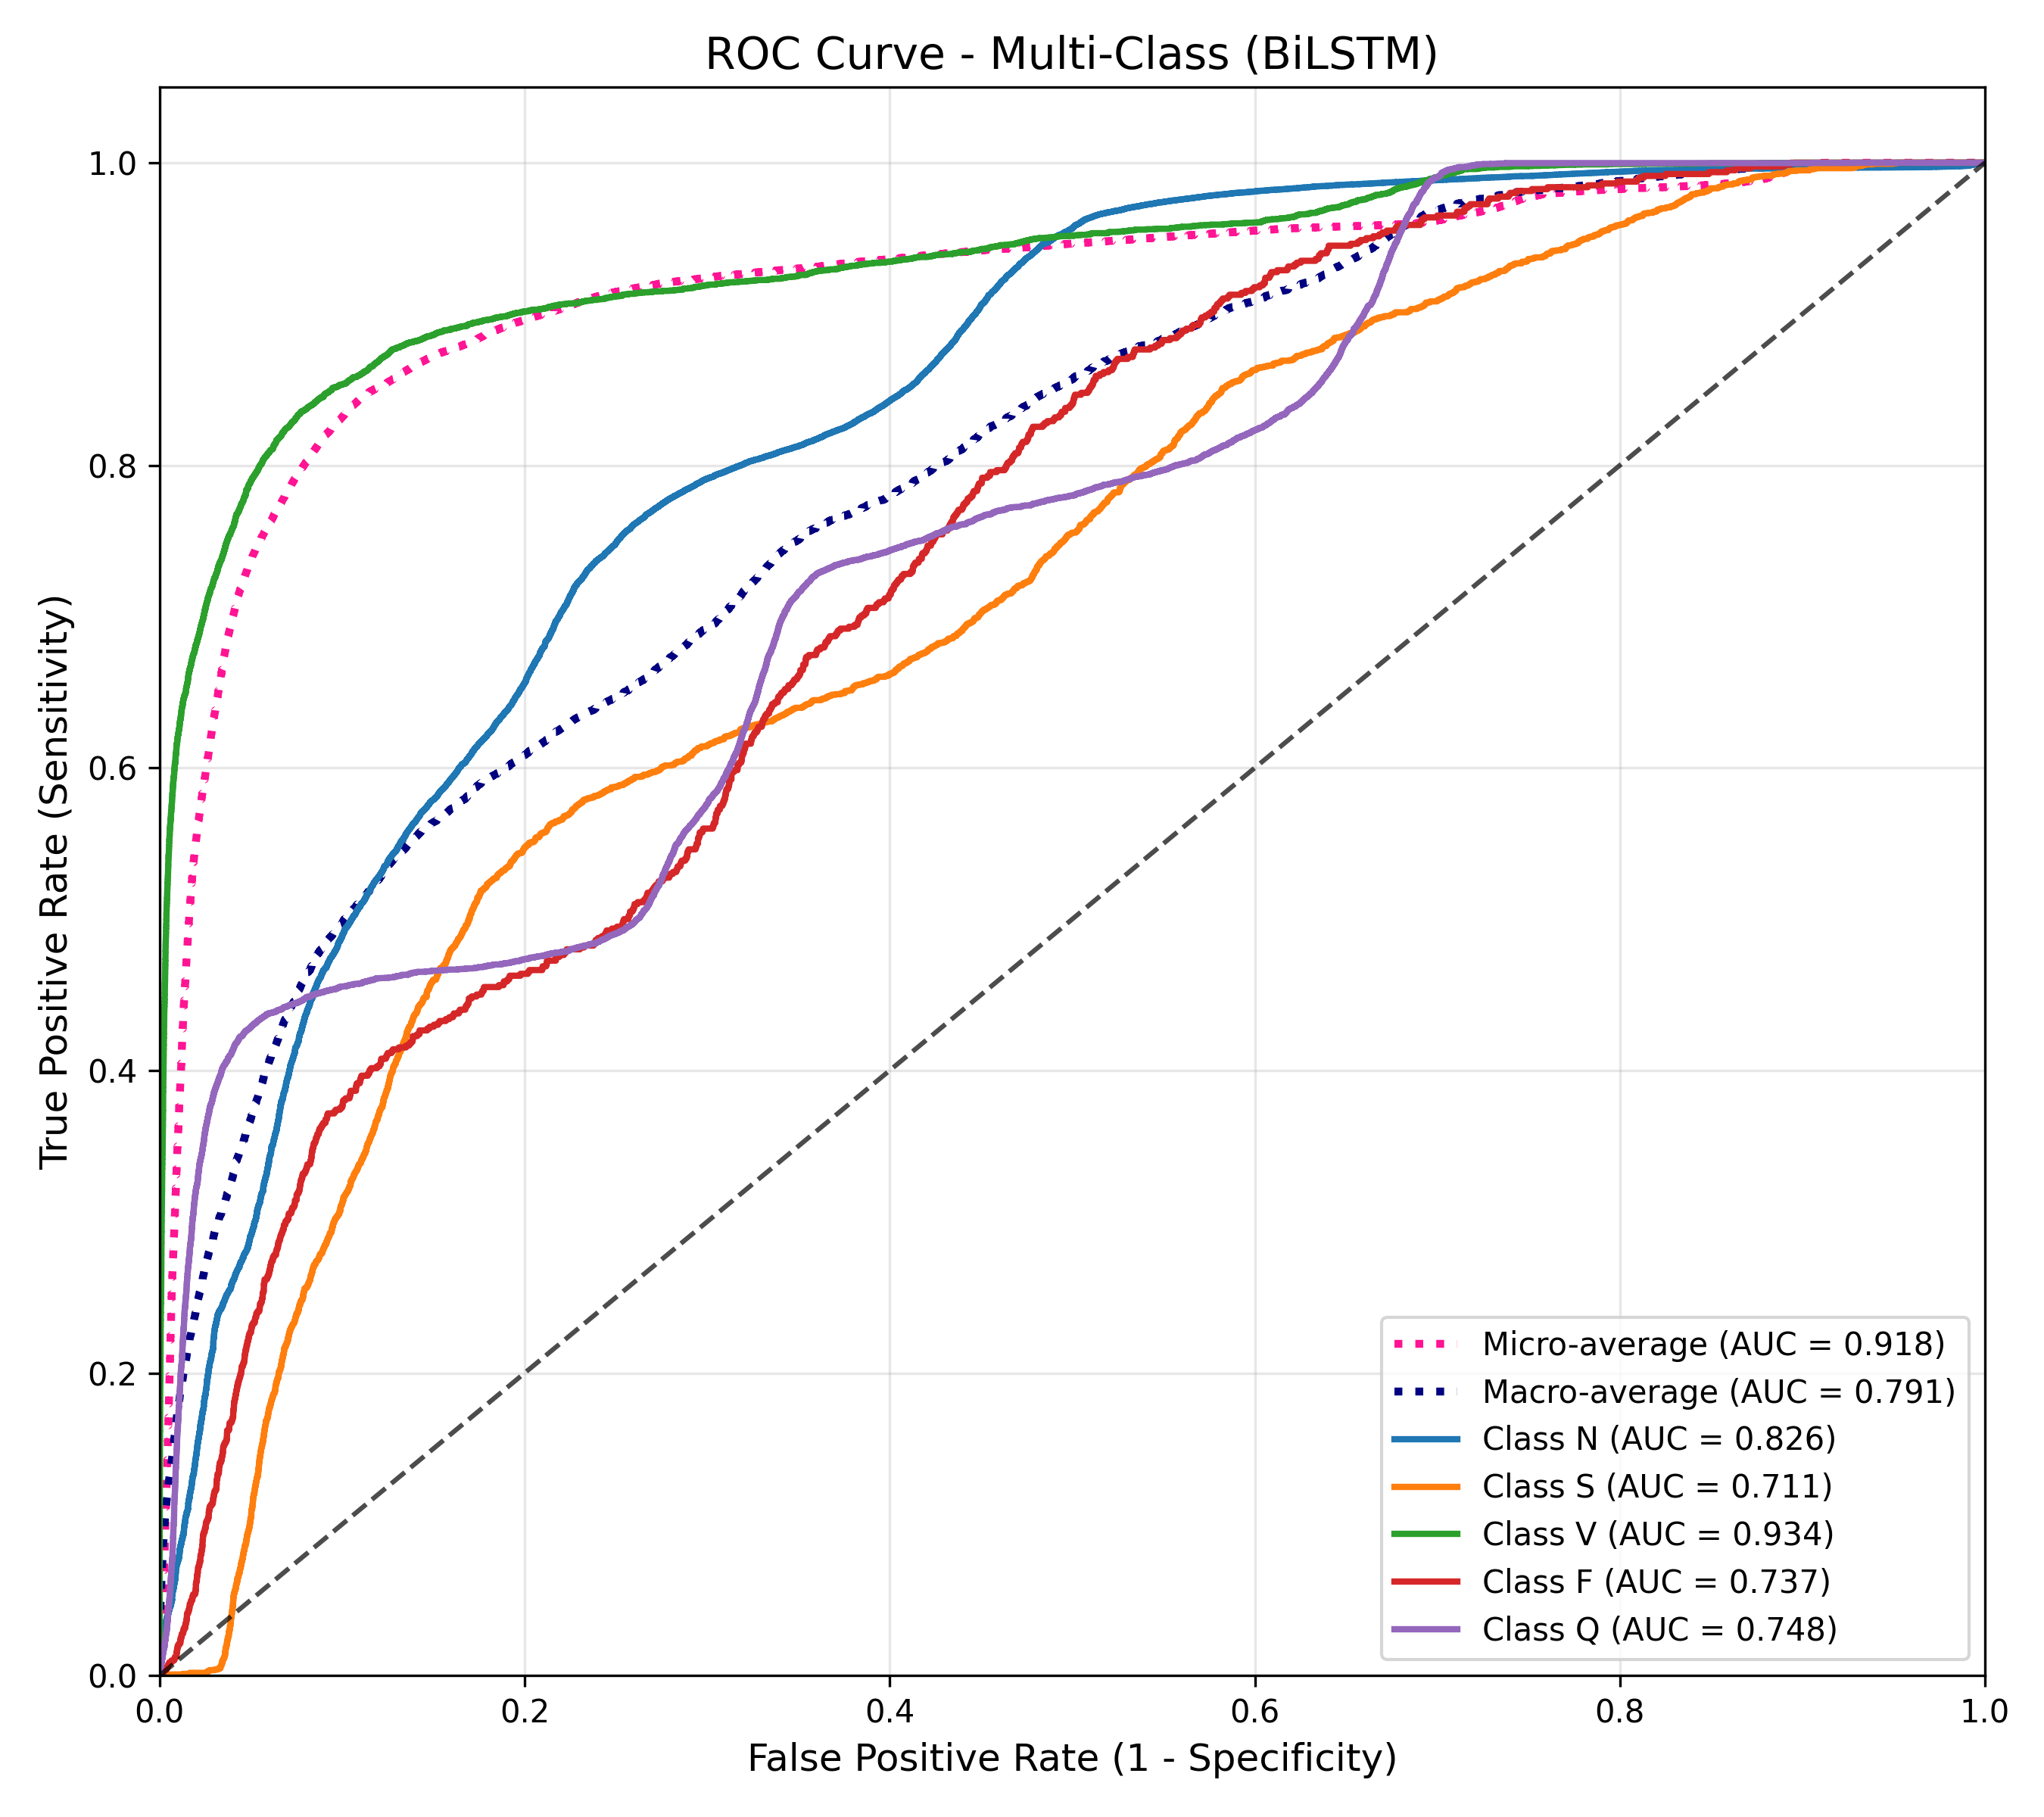

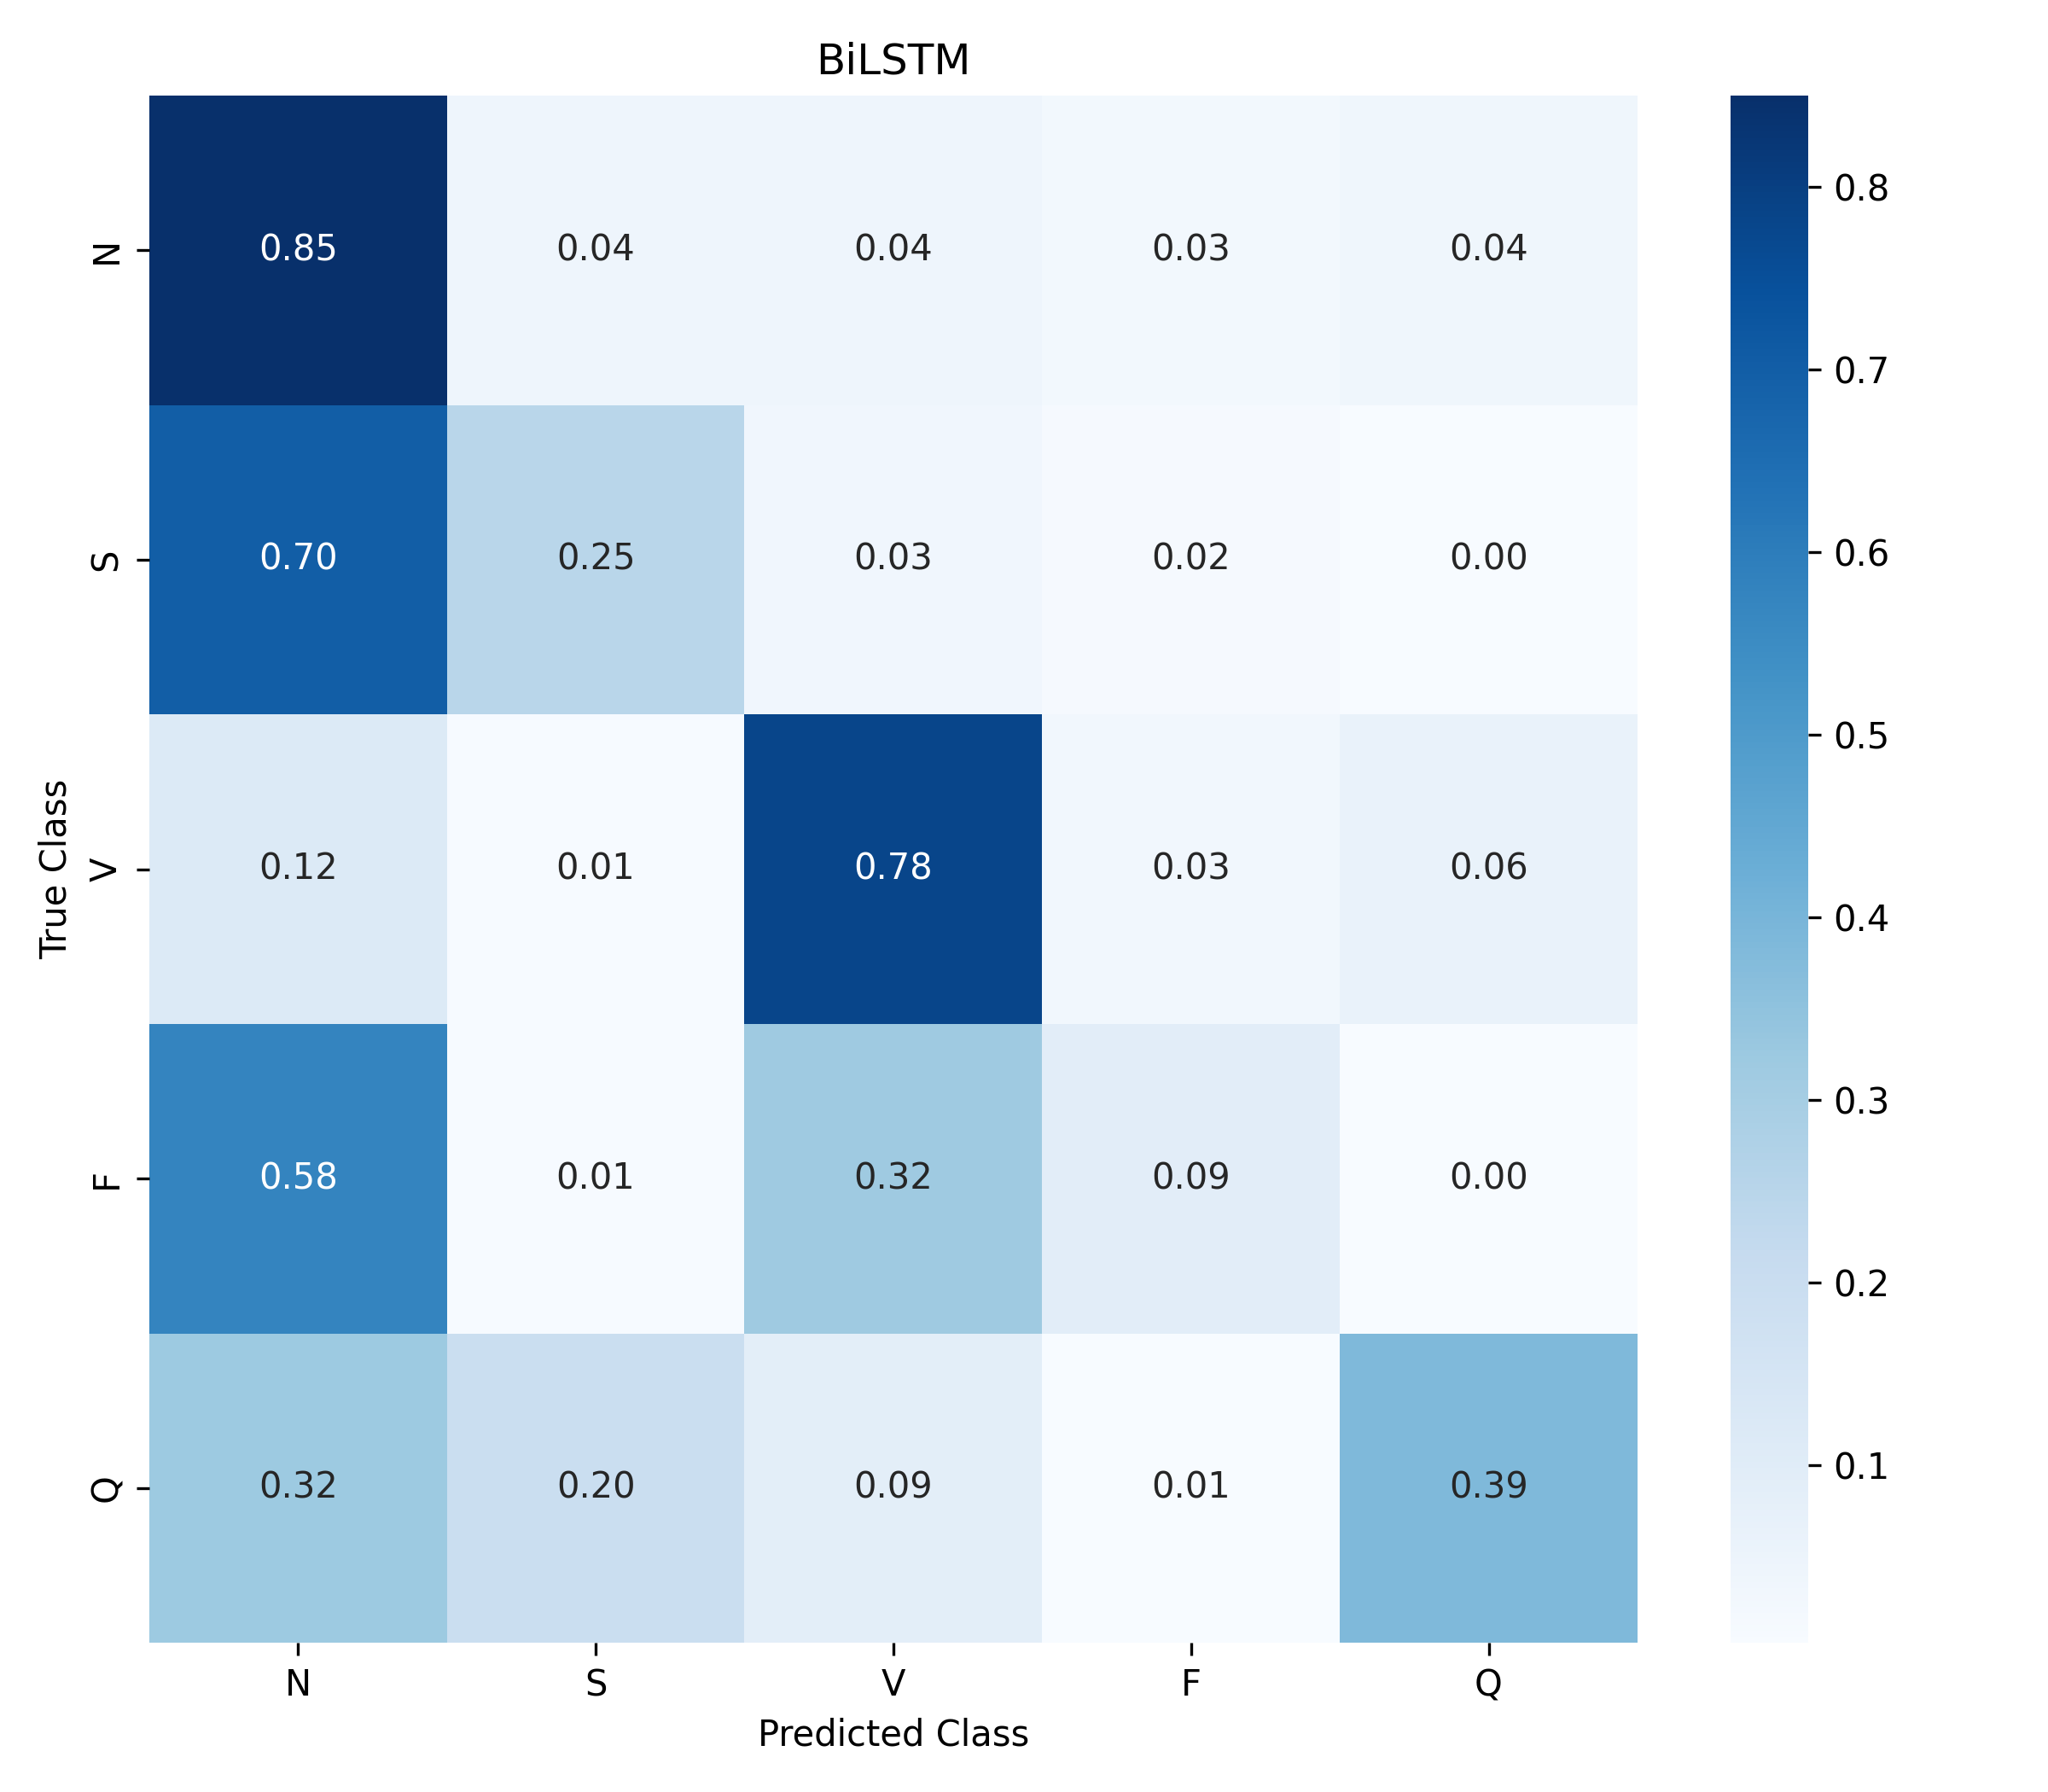

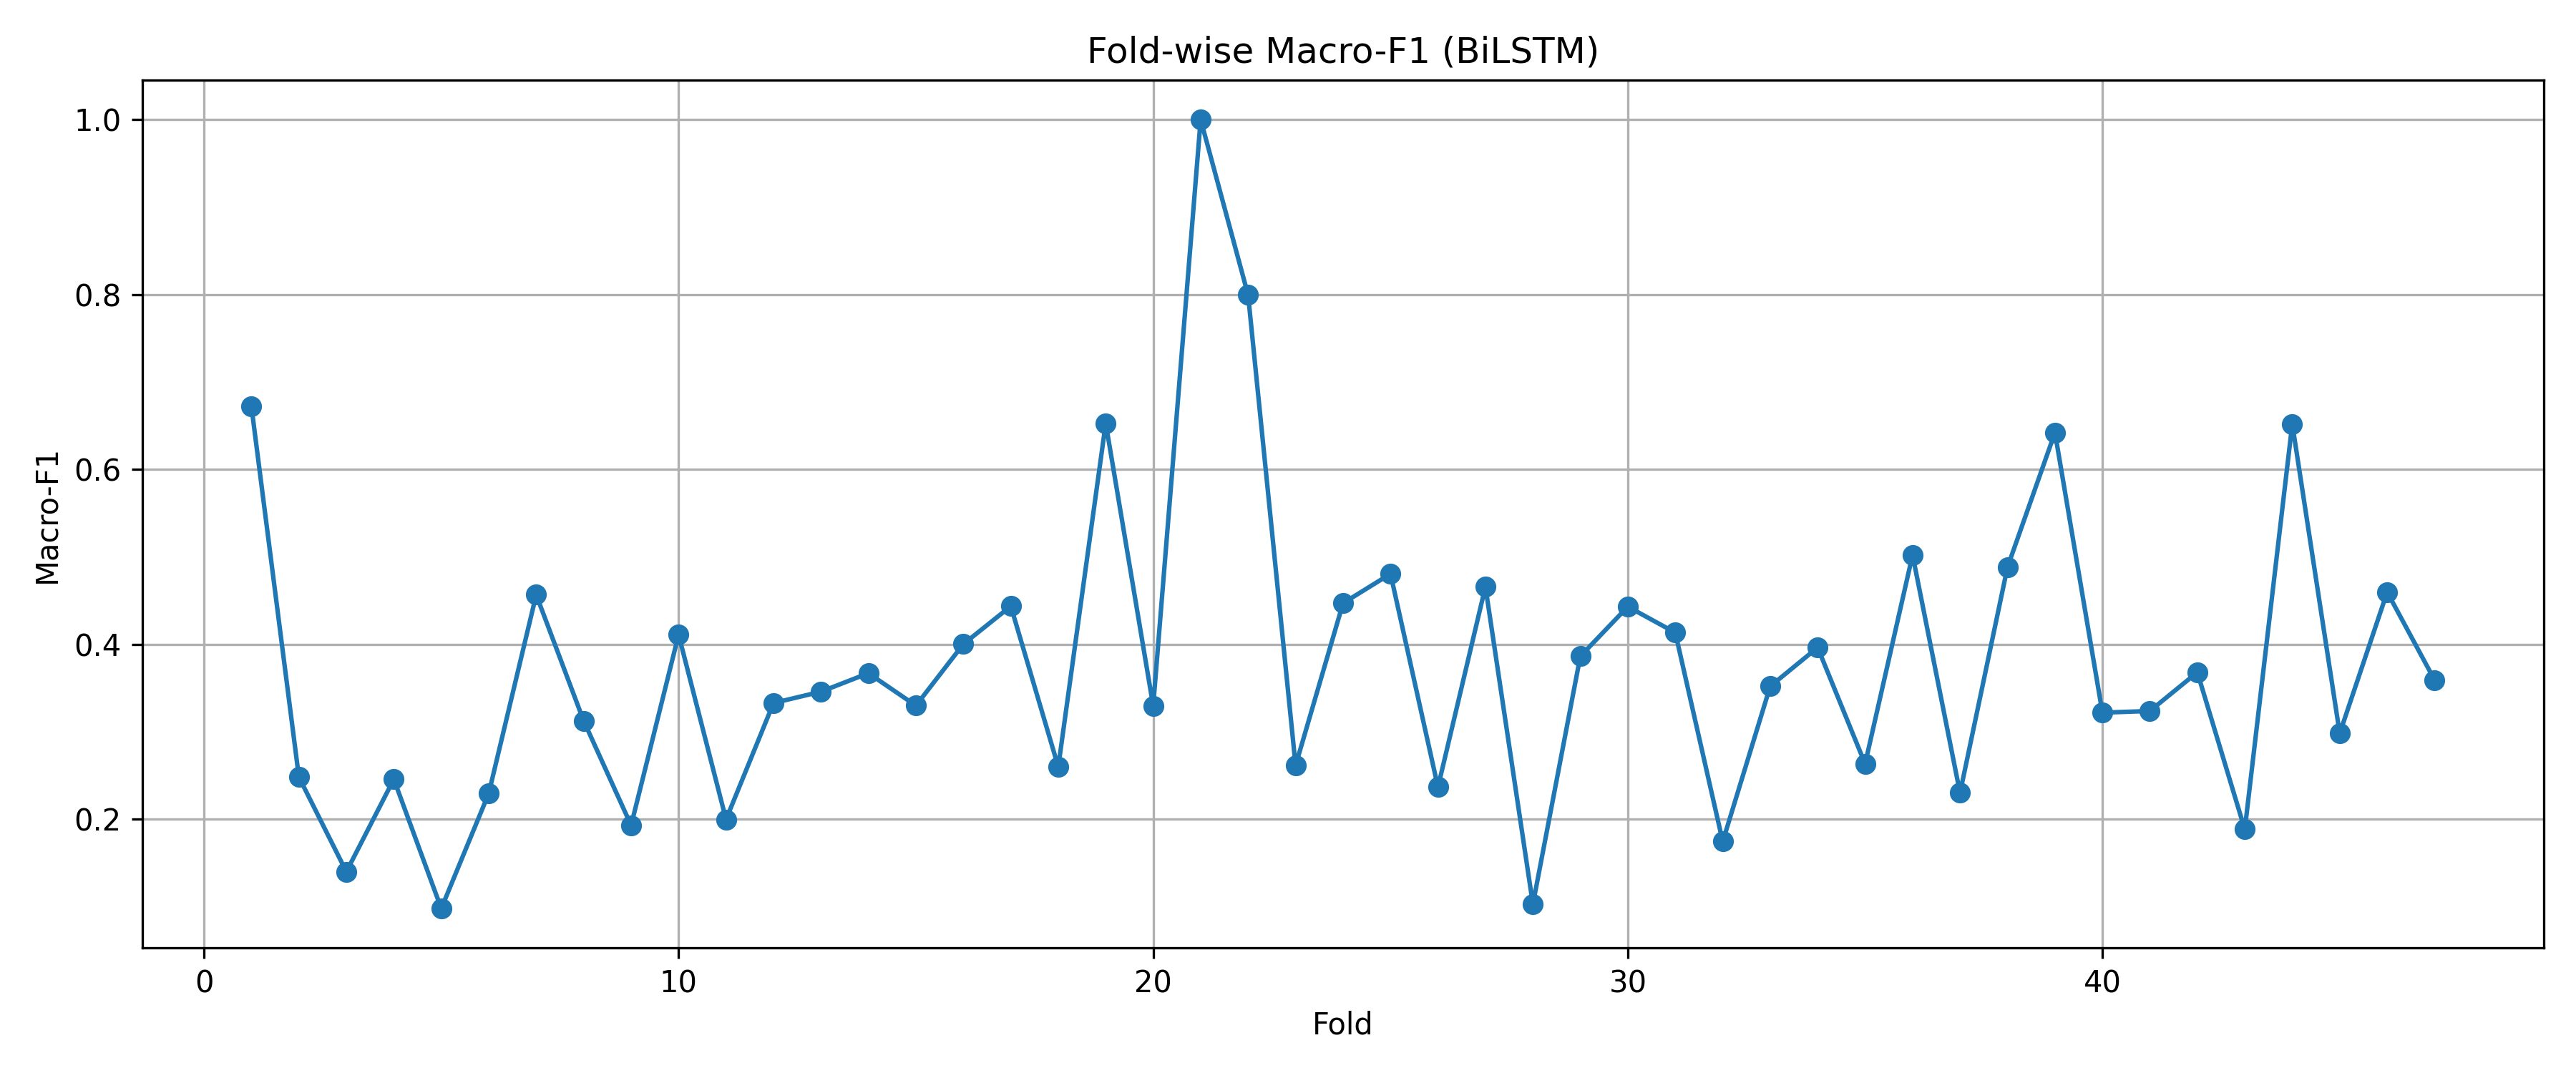

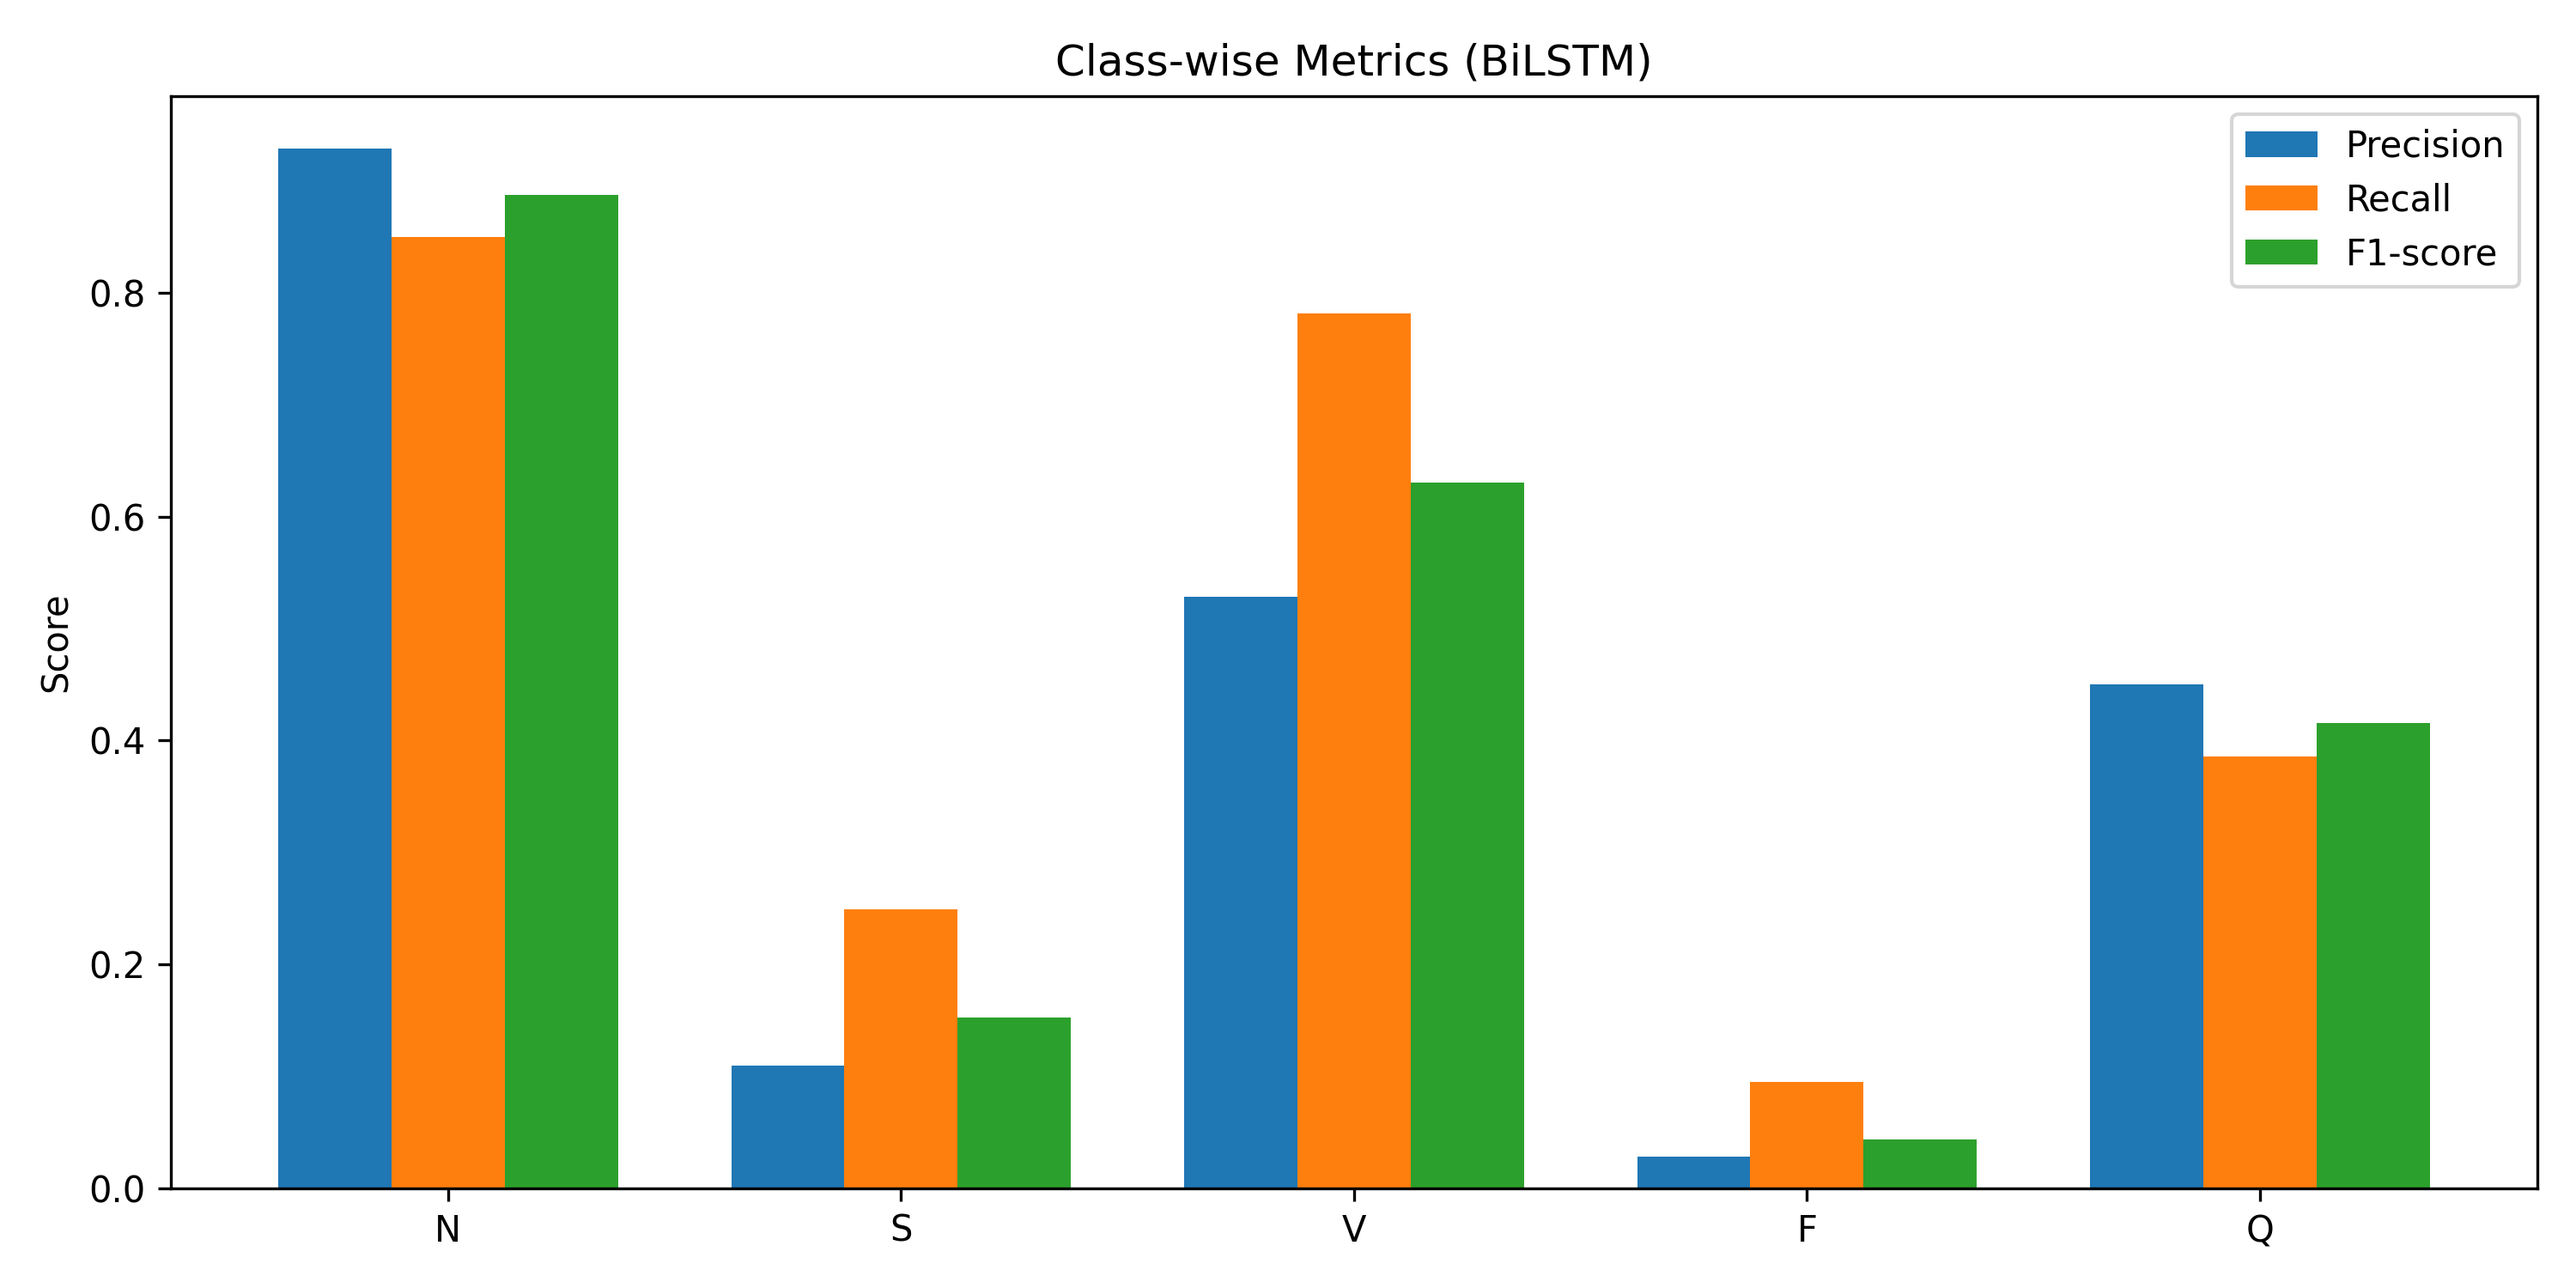

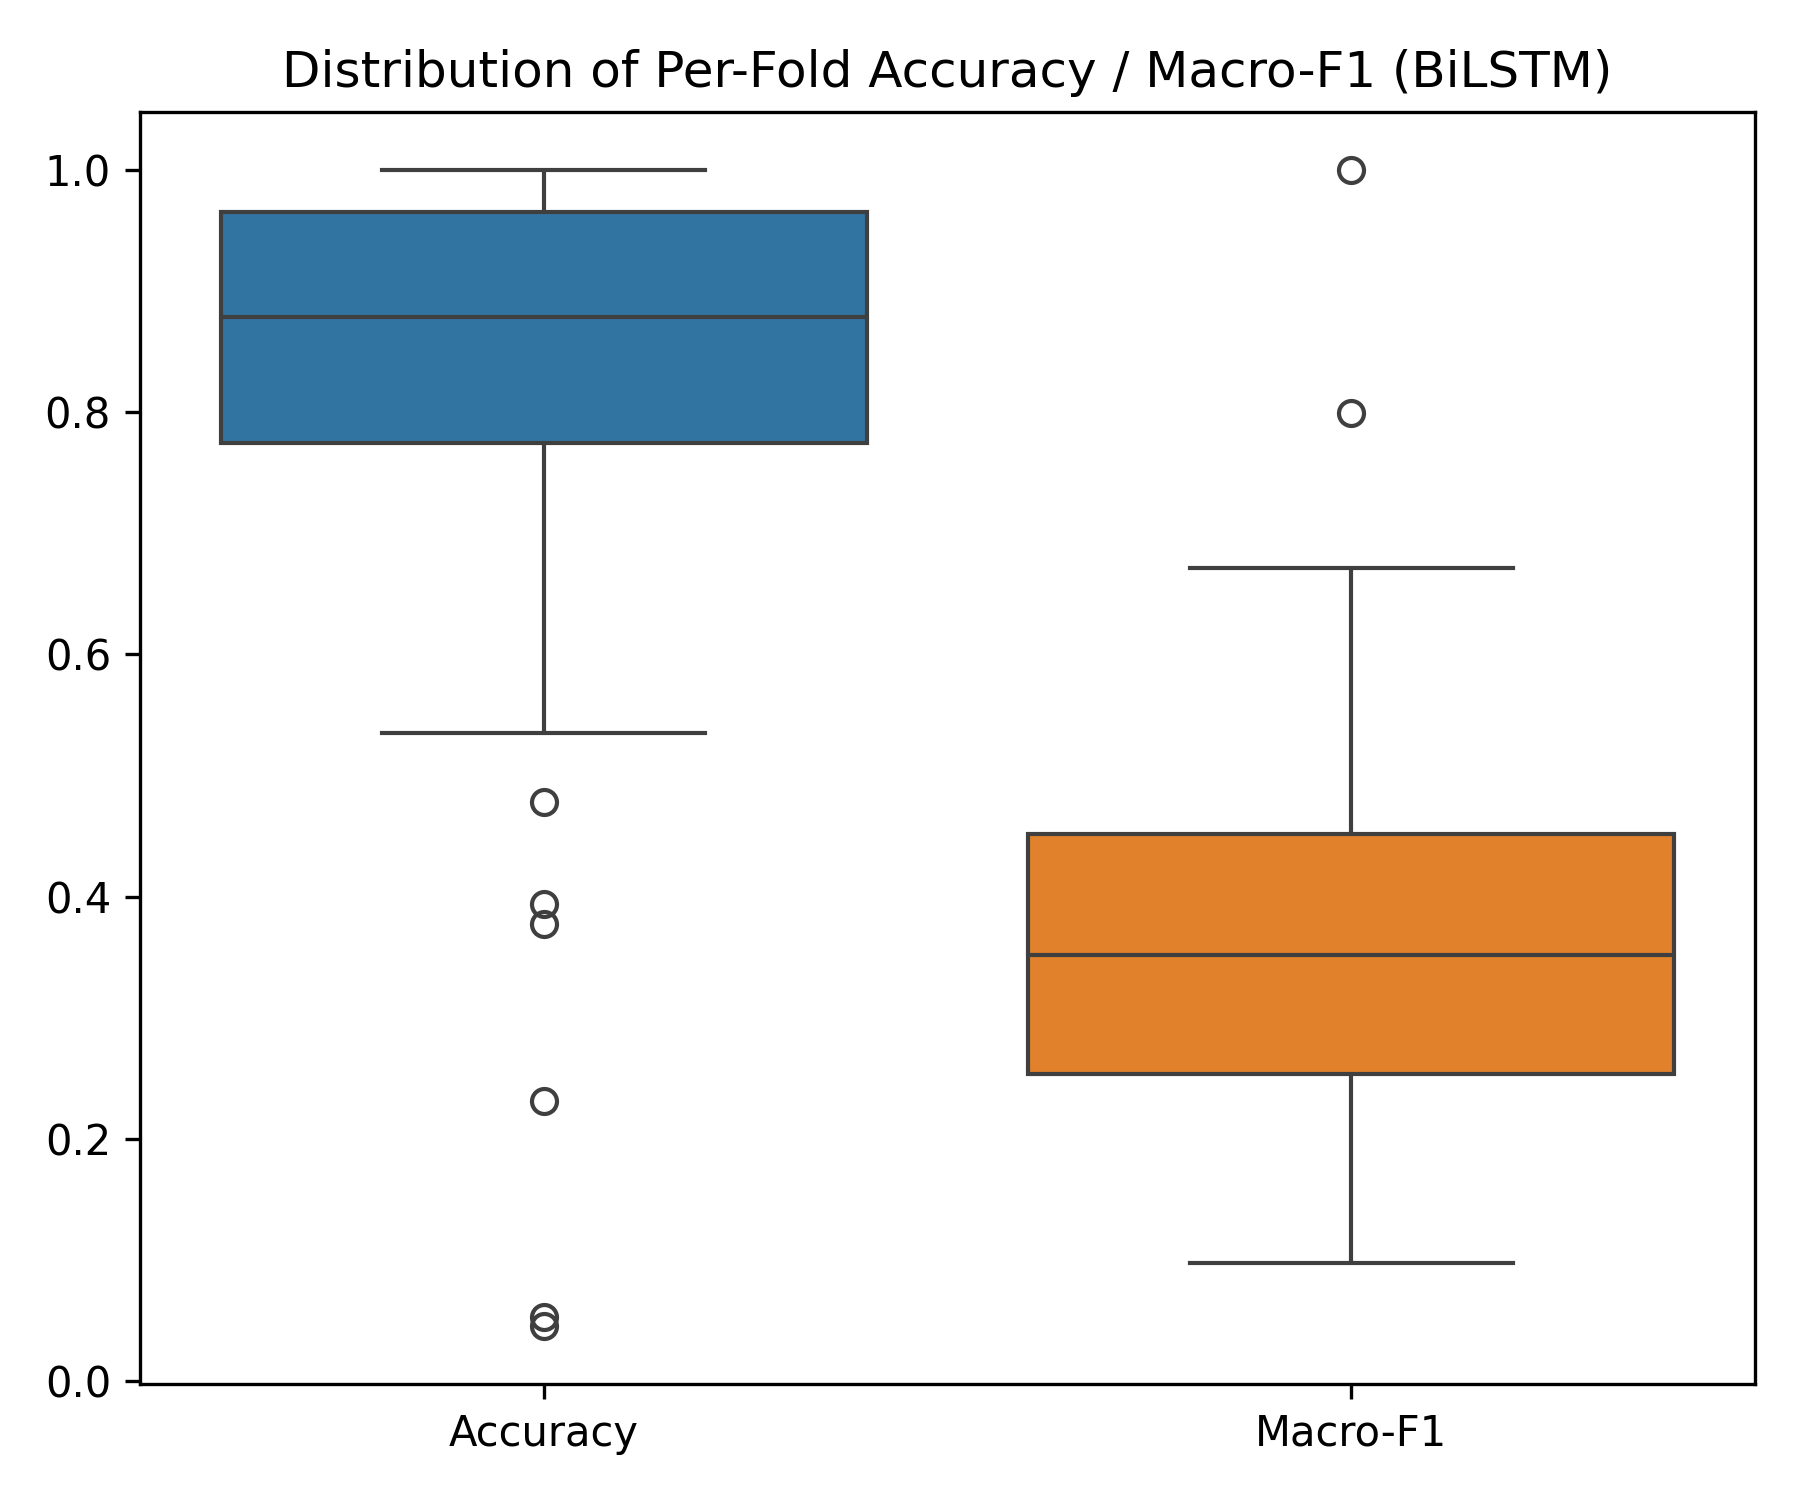

In [9]:
# ========================
# Step 9 — Visualization 
# ========================
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from IPython.display import Image, display

CLASS_NAMES = ["N", "S", "V", "F", "Q"]
N_CLASSES = len(CLASS_NAMES)

# =====================================================
# Load Results
# =====================================================
with open("results/loso_summary.json", "r") as f:
    summary = json.load(f)

with open("results/all_results.pkl", "rb") as f:
    all_results = pickle.load(f)

# =====================================================
# 1. Normalized Confusion Matrix
# =====================================================
cm = np.array(summary["aggregate_confusion_matrix"])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title("BiLSTM")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig("results/confusion_matrix_normalized.png", dpi=300)
plt.close()

# =====================================================
# 2. Multi-Class ROC Curve (One-vs-Rest)
# =====================================================
# Aggregate all labels and predicted probabilities across folds
all_labels = np.concatenate([r["labels"] for r in all_results])
all_probs = np.concatenate([r["logits"] for r in all_results])  # (N_samples, 5)

# Binarize labels for One-vs-Rest evaluation (e.g., class 2 -> [0, 0, 1, 0, 0])
y_test_bin = label_binarize(all_labels, classes=[0, 1, 2, 3, 4])

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC & AUC for each class
for i in range(N_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(N_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(N_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= N_CLASSES
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot ROC Curves
plt.figure(figsize=(9, 8))

# Plot Micro & Macro
plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro-average (AUC = {roc_auc['micro']:.3f})",
         color="deeppink", linestyle=":", linewidth=2.5)

plt.plot(fpr["macro"], tpr["macro"],
         label=f"Macro-average (AUC = {roc_auc['macro']:.3f})",
         color="navy", linestyle=":", linewidth=2.5)

# Plot Per-Class Curves
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, color in zip(range(N_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})")

# Chance line
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=12)
plt.title("ROC Curve - Multi-Class (BiLSTM)", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("results/roc_curve.png", dpi=300)
plt.close()

# =====================================================
# 3. Fold-wise Macro-F1
# =====================================================
folds = [r["fold"] for r in all_results]
macro_f1 = [r["macro_f1"] for r in all_results]

plt.figure(figsize=(12, 5))
plt.plot(folds, macro_f1, marker="o")
plt.title("Fold-wise Macro-F1 (BiLSTM)")
plt.xlabel("Fold")
plt.ylabel("Macro-F1")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/fold_macro_f1.png", dpi=300)
plt.close()

# =====================================================
# 4. Class-wise Precision / Recall / F1
# =====================================================
report = summary["classification_report"]
precision = [report[c]["precision"] for c in CLASS_NAMES]
recall = [report[c]["recall"] for c in CLASS_NAMES]
f1 = [report[c]["f1-score"] for c in CLASS_NAMES]

x = np.arange(len(CLASS_NAMES))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")
plt.xticks(x, CLASS_NAMES)
plt.ylabel("Score")
plt.title("Class-wise Metrics (BiLSTM)")
plt.legend()
plt.tight_layout()
plt.savefig("results/classwise_metrics.png", dpi=300)
plt.close()

# =====================================================
# 5. Performance Boxplot
# =====================================================
accs = [r["accuracy"] for r in all_results]
df = pd.DataFrame({"Accuracy": accs, "Macro-F1": macro_f1})

plt.figure(figsize=(6, 5))
sns.boxplot(data=df)
plt.title("Distribution of Per-Fold Accuracy / Macro-F1 (BiLSTM)")
plt.tight_layout()
plt.savefig("results/performance_boxplot.png", dpi=300)
plt.close()

print("Saved visualizations to results/*.png")

# Display images in notebook
for fname in [
    "roc_curve.png",
    "confusion_matrix_normalized.png",
    "fold_macro_f1.png",
    "classwise_metrics.png",
    "performance_boxplot.png"
]:
    display(Image(filename=f"results/{fname}"))